NOTE: From Exploratory Data Analysis:

*   Dataset has 11 (1.1%) duplicate rows i.e DUPLICATE GROUPS.
*   `age` is highly overall correlated with `concrete_compressive_strength`.
*   `concrete_compressive_strength` is highly overall correlated with `age`.
*   `superplasticizer` is highly overall correlated with `water`.
*   `water` is highly overall correlated with `superplasticizer`.
*   `blast_furnace_slag` has 471 (45.7%) zeros.
*   `fly_ash` has 566 (55.0%) zeros.  
*   `superplasticizer` has 379 (36.8%) zeros.

In [58]:
# dependencies
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# reproducibility
seed = 2006
np.random.seed(2006)
# paths
base_path = Path('/content/drive/MyDrive/Concrete Compressive Strength Prediction')
raw_data = base_path / '01_Dataset' / 'Raw' / 'concrete_data.csv'
proces_data = base_path / '01_Dataset' / 'Processed'
fig_pre = base_path / '03_Figures' / 'pre-processing'

In [59]:
df_raw = pd.read_csv(raw_data)
df_raw.shape

(1030, 9)

In [60]:
df_raw.sample(5)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
522,284.0,15.0,141.0,179.0,5.5,842.0,801.0,56,44.52
213,230.0,0.0,118.3,195.5,4.6,1029.4,758.6,100,35.34
913,298.0,0.0,107.0,164.0,13.0,953.0,784.0,28,35.86
289,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,3,7.32
398,160.0,128.0,122.0,182.0,6.4,824.0,879.0,28,39.40


In [61]:
# stats
df_raw.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [62]:
df_raw.info() # no nullity as already observed in EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [63]:
df_raw.duplicated().value_counts()

,count
False,1005
True,25


In [64]:
df_clean = df_raw.copy()
df_clean.drop_duplicates(inplace=True)

In [65]:
df_clean.duplicated().value_counts()

,count
False,1005


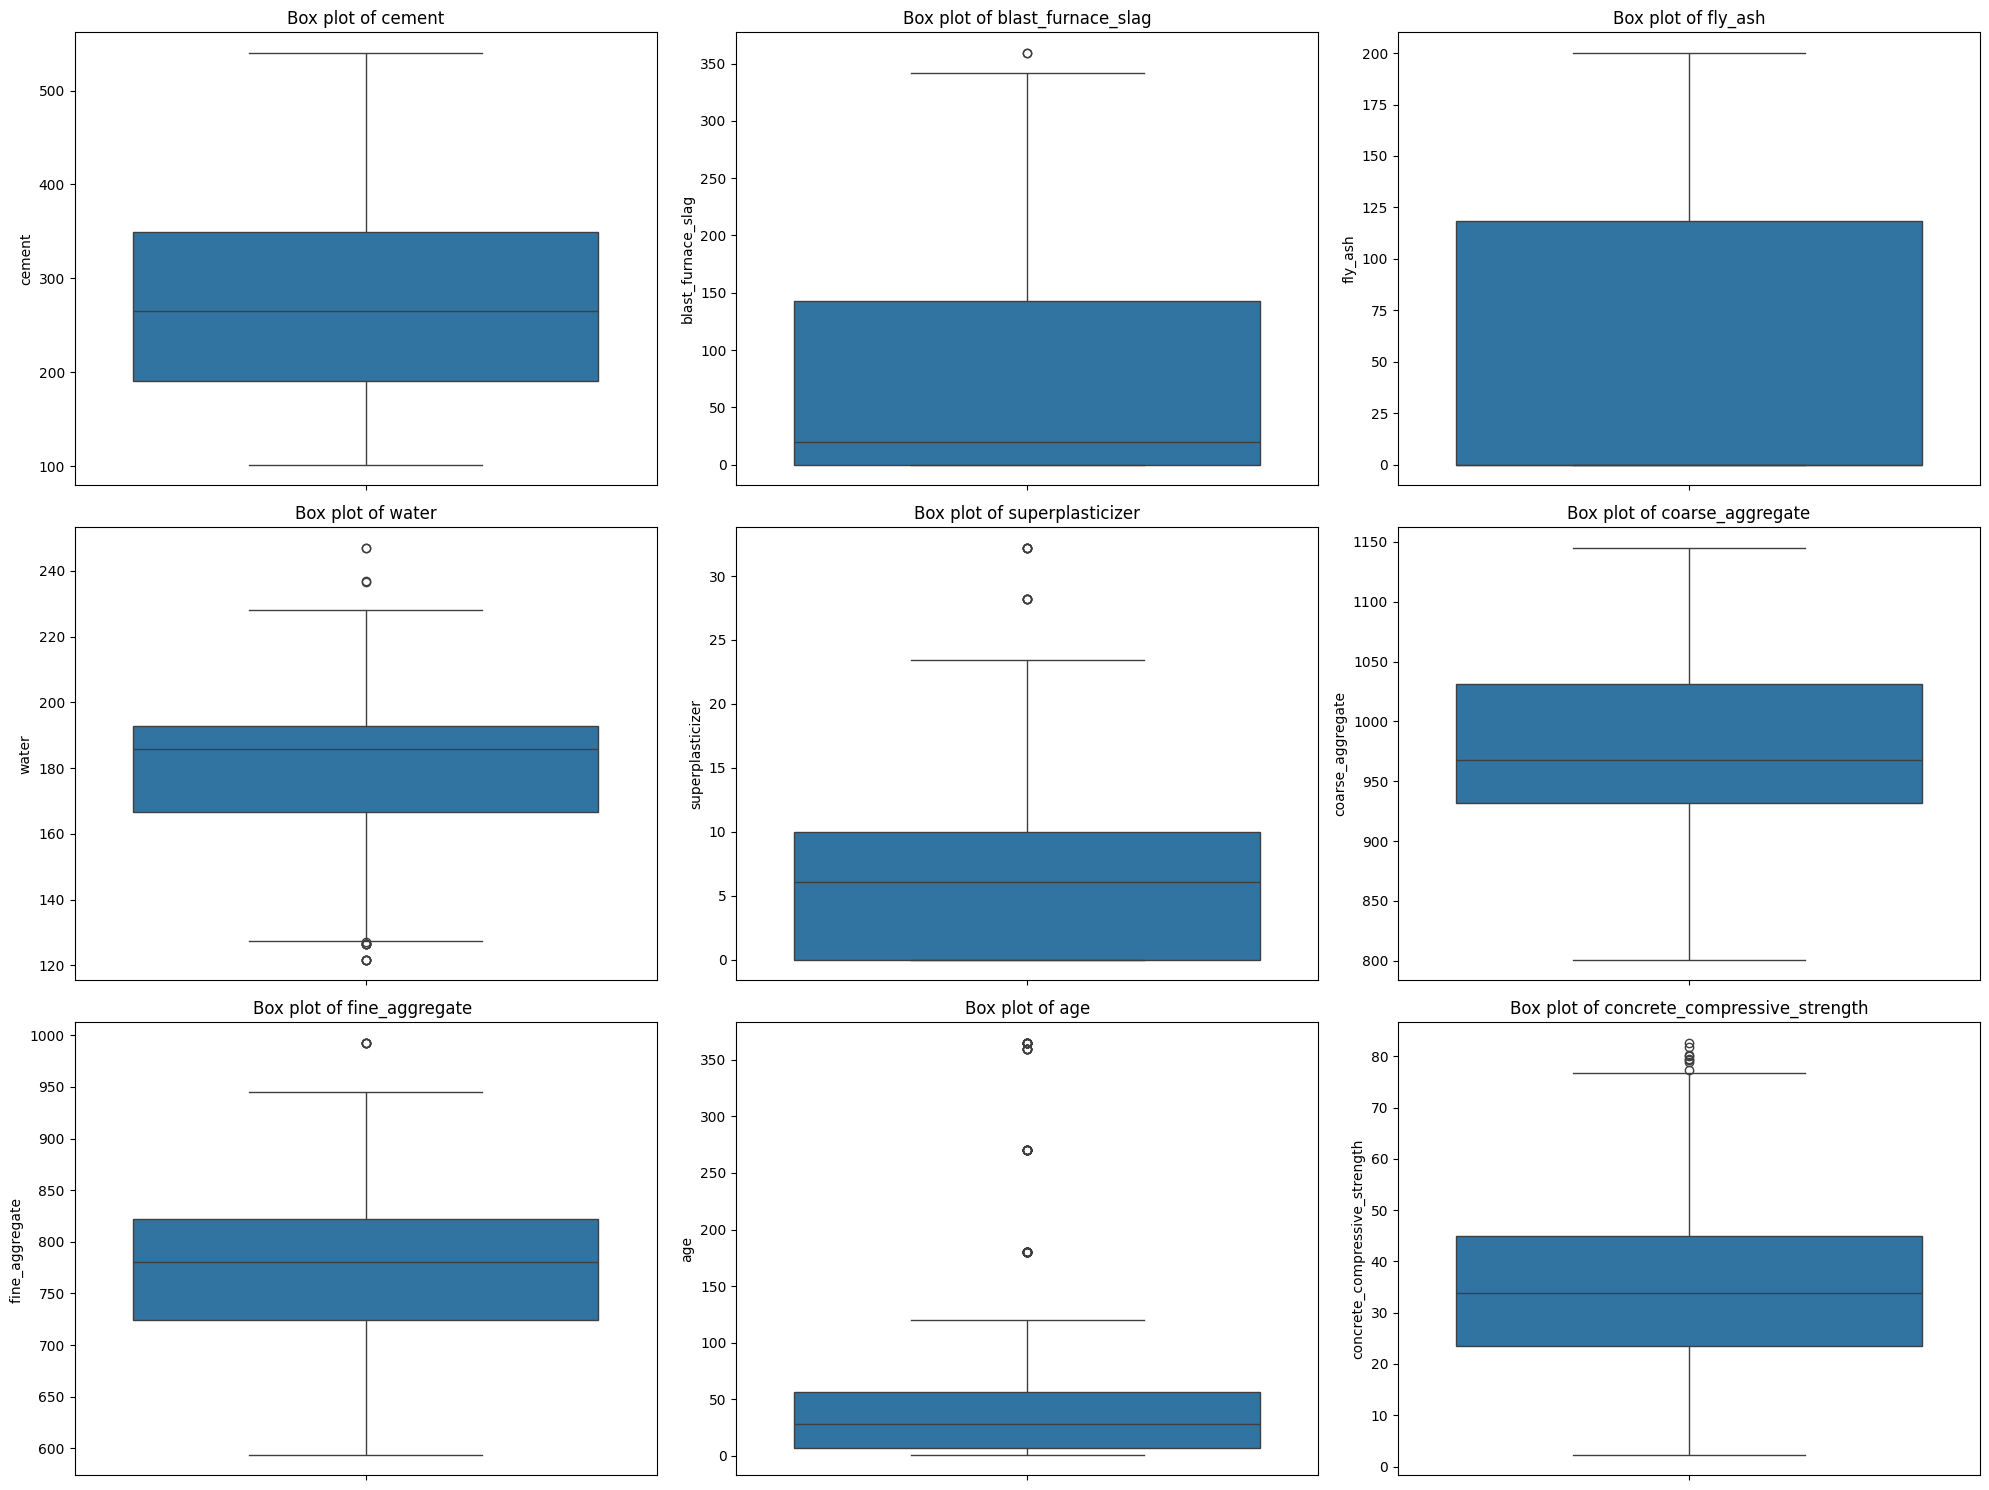

In [66]:
# Outlier detection
# visualization
plt.figure(figsize=(20, 15))
for i, column in enumerate(df_clean.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_clean[column])
    plt.title(f'Box plot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.savefig(fig_pre / 'boxplot')
plt.show() # no signifcance outliers, maintain outliers for natural variance

In [67]:
# WATER CEMENT RATIO feature engineered
df_clean['water_cement_ratio'] = df_clean['water'] / df_clean['cement'].replace(0, np.nan)
# handle for zeros, though unlikely

In [68]:
df_clean.sample(5)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,water_cement_ratio
408,178.0,129.8,118.6,179.9,3.6,1007.3,746.8,3,20.73,1.010674
287,181.4,0.0,167.0,169.6,7.6,1055.6,777.8,56,35.57,0.934950
71,313.3,262.2,0.0,175.5,8.6,1046.9,611.8,3,28.80,0.560166
514,424.0,22.0,132.0,168.0,8.9,822.0,750.0,56,74.36,0.396226
118,425.0,106.3,0.0,153.5,16.5,852.1,887.1,28,60.29,0.361176


### Comprehensive Data Visualizations

To understand the data distribution, relationships between variables, and potential patterns, we will generate the following visualizations:

1.  **Histograms and KDE plots**: To visualize the distribution of each feature.
2.  **Correlation Heatmap**: To show the linear relationships between all numerical features.
3.  **Scatter Plots**: To examine the relationship between individual features and the target variable (`concrete_compressive_strength`).

#### 1. Distribution of Features (Histograms and KDE plots)

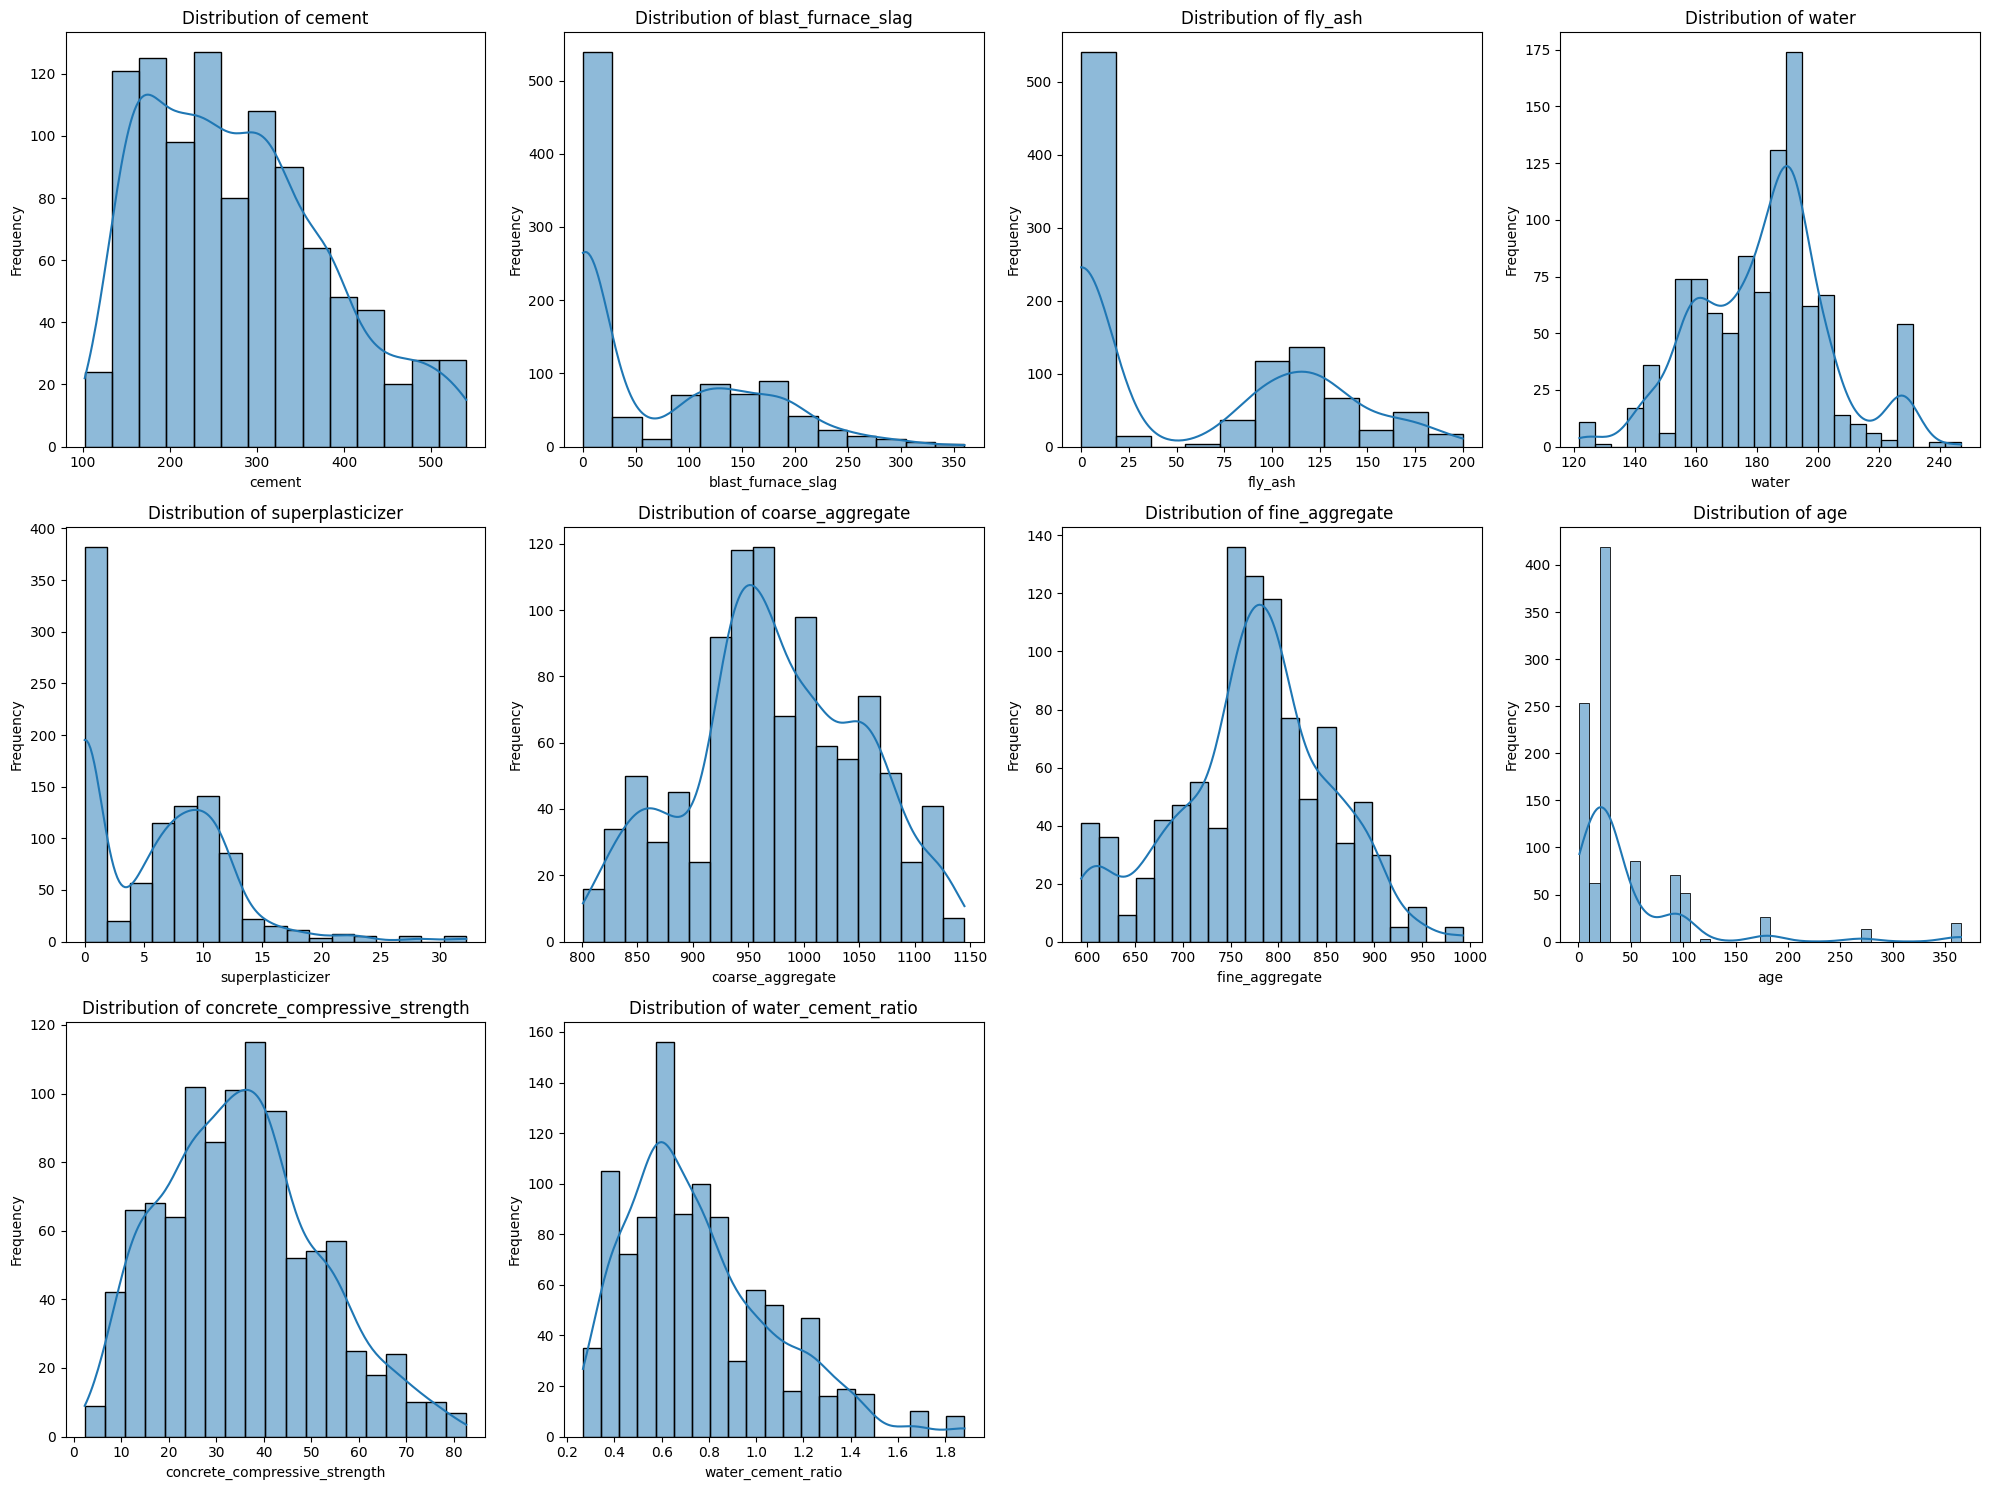

In [69]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(df_clean.columns):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid to fit the new water_cement_ratio column
    sns.histplot(df_clean[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
plt.tight_layout()
output_filepath = fig_pre / 'feature_distributions.png'
output_filepath.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_filepath)
plt.show()

#### 2. Correlation Heatmap

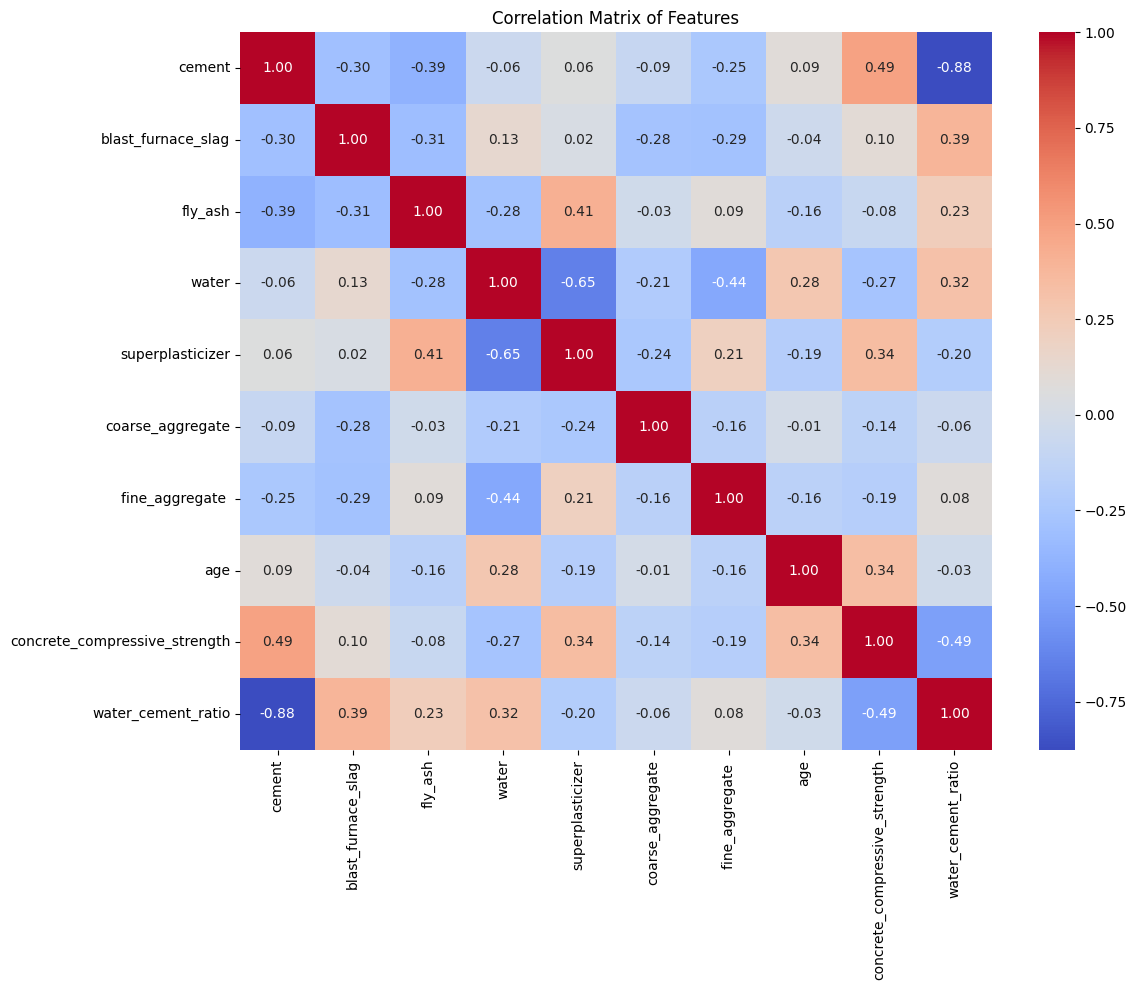

In [70]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.tight_layout()
output_filepath = fig_pre / 'correlation_heatmap.png'
plt.savefig(output_filepath)
plt.show()

#### 3. Scatter Plots with Target Variable

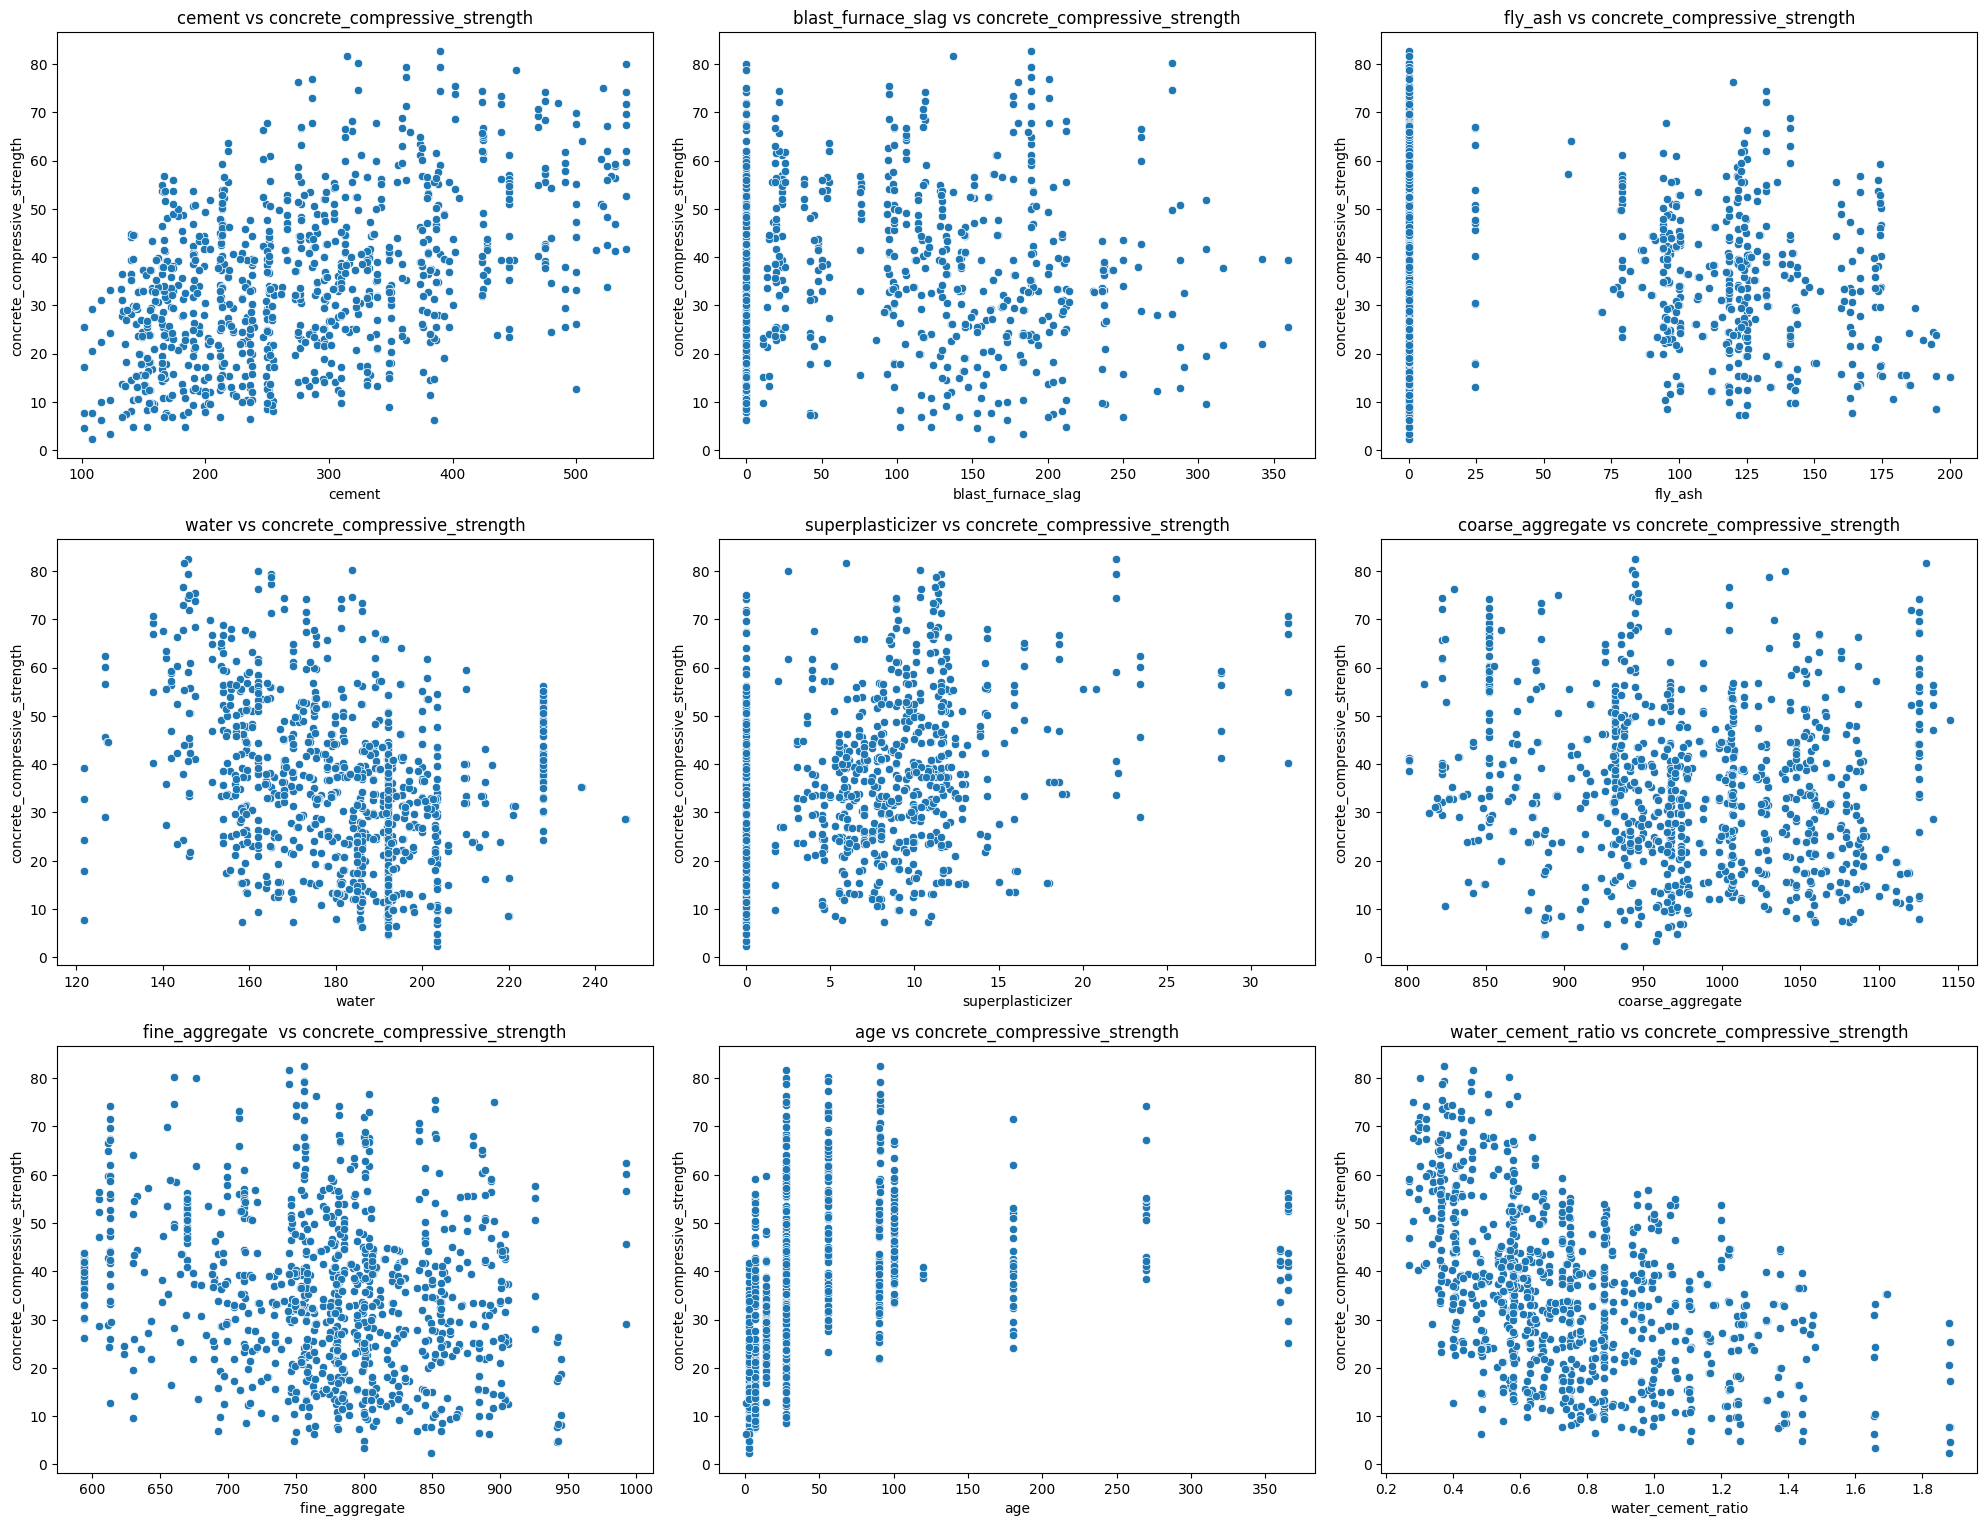

In [71]:
target_variable = 'concrete_compressive_strength'
features = [col for col in df_clean.columns if col != target_variable]

plt.figure(figsize=(20, 20))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)
    sns.scatterplot(x=df_clean[feature], y=df_clean[target_variable])
    plt.title(f'{feature} vs {target_variable}')
    plt.xlabel(feature)
    plt.ylabel(target_variable)
plt.tight_layout()
output_filepath = fig_pre / 'feature_vs_target_scatterplots.png'
plt.savefig(output_filepath)
plt.show()

In [72]:
# save the df_clean csv
df_clean.to_csv(proces_data / 'df_clean.csv', index=False)